# activity at 0.5 uM Enzyme, 3 uM substrate

In [3]:
import pandas as pd
import os
source_plate_info = os.getcwd() + "/260113_normalize_all.csv"
df_source_plate_info  = pd.read_csv(source_plate_info)

df_source_plate_info.head()

,Unnamed: 0,design_name,plate_number,well_id,normalize_buffer_volume_ul
0,0,chainA_L22A,5,A1,120.738994
1,1,chainA_L22D,5,A2,115.471698
2,2,chainA_L22E,5,A3,117.515723
3,3,chainA_L22F,5,A4,115.000000
4,4,chainA_L22G,5,A5,123.883648


In [4]:
import pandas as pd
import re

file_path = "/net/expdata/users/achen918/Plate_reader/Data/260114_zn45_ssm_4_plates/Book2.csv"

# Read raw CSV without assuming headers
raw = pd.read_csv(file_path, header=None, dtype=str)

def time_to_seconds(t):
    """Convert HH:MM:SS or M:SS to seconds."""
    h, m, s = [int(x) for x in t.split(":")]
    return h * 3600 + m * 60 + s

def parse_channel(raw_df, channel_label):
    """
    Parse one fluorescence channel block (e.g. '485,528' or '485,610')
    """
    records = []

    # Find all rows that exactly match the channel label
    channel_rows = raw_df.index[raw_df[0] == channel_label]

    for start_idx in channel_rows:
        # Header row is 2 lines below the channel label
        header_idx = start_idx + 2
        header = raw_df.iloc[header_idx].tolist()

        # Well columns start after Time and Temperature
        well_cols = header[3:]
        well_col_indices = list(range(3, 3 + len(well_cols)))

        # Data rows start after header
        data_start = header_idx + 1

        for i in range(data_start, len(raw_df)):
            row = raw_df.iloc[i]

            # Stop if we hit an empty line or a new channel
            if pd.isna(row[1]) or row[0] in ["485,528", "485,610"]:
                break

            time_str = row[1]
            time_sec = time_to_seconds(time_str)

            for well, col_idx in zip(well_cols, well_col_indices):
                value = row[col_idx]
                if pd.isna(value):
                    continue

                records.append({
                    "well_name": well,
                    "time": time_sec,
                    channel_label: float(value)
                })

    return pd.DataFrame(records)

# Parse both channels
df_gfp = parse_channel(raw, "485,528")
df_mscarlet = parse_channel(raw, "485,610")

# Rename columns to desired names
df_gfp = df_gfp.rename(columns={"485,528": "sfGFP_RFU"})
df_mscarlet = df_mscarlet.rename(columns={"485,610": "mscarlet_RFU"})

# Merge channels
df = pd.merge(
    df_gfp,
    df_mscarlet,
    on=["well_name", "time"],
    how="outer"
).sort_values(["well_name", "time"]).reset_index(drop=True)

print(df.head())


  well_name  time  sfGFP_RFU  mscarlet_RFU
0        A1     0     9831.0           NaN
1        A1    64        NaN        5076.0
2        A1   180    10976.0           NaN
3        A1   244        NaN        5155.0
4        A1   360    11214.0           NaN


## Add mapping from 4 source 96 well plates to 1 384 measurement plate

In [5]:
import string

def map_source_plate(well):
    """
    Map 384-well well_name -> (source_plate_number, source_plate_well_id)
    """
    # Split row letter(s) and column number
    row = ''.join(filter(str.isalpha, well))
    col = int(''.join(filter(str.isdigit, well)))

    # Determine if top or bottom half of 384-well plate
    if row in list(string.ascii_uppercase[:8]):  # A–H
        base_plate = 5
        source_row = row
    else:  # I–P
        base_plate = 7
        source_row = string.ascii_uppercase[
            list(string.ascii_uppercase[8:16]).index(row)
        ]

    # Odd vs even column determines which of the two plates
    if col % 2 == 1:
        source_plate_number = base_plate
    else:
        source_plate_number = base_plate + 1

    # Map 384 column to 96 column (1–12)
    source_col = (col + 1) // 2

    source_plate_well_id = f"{source_row}{source_col}"

    return source_plate_number, source_plate_well_id


# Apply mapping
df_gfp[["source_plate_number", "source_plate_well_id"]] = (
    df_gfp["well_name"]
    .apply(lambda w: pd.Series(map_source_plate(w)))
)

df_gfp.head()


,well_name,time,sfGFP_RFU,source_plate_number,source_plate_well_id
0,A1,0,9831.0,5,A1
1,A2,0,10242.0,6,A1
2,A3,0,9848.0,5,A2
3,A4,0,10928.0,6,A2
4,A5,0,10254.0,5,A3


In [6]:
df_merged = df_gfp.merge(
    df_source_plate_info,
    left_on=["source_plate_number", "source_plate_well_id"],
    right_on=["plate_number", "well_id"],
    how="left"
)
kept_columns = ['well_name', 'time', 'sfGFP_RFU', 'source_plate_number',
       'source_plate_well_id', 'design_name']

df_progress_in_time = df_merged[kept_columns].copy()

In [7]:
df_progress_in_time

,well_name,time,sfGFP_RFU,source_plate_number,source_plate_well_id,design_name
0,A1,0,9831.0,5,A1,chainA_L22A
1,A2,0,10242.0,6,A1,chainA_F52K
2,A3,0,9848.0,5,A2,chainA_L22D
3,A4,0,10928.0,6,A2,chainA_F52L
4,A5,0,10254.0,5,A3,chainA_L22E
...,...,...,...,...,...,...
15739,P20,7200,12182.0,8,H10,blank
15740,P21,7200,22245.0,7,H11,chainA_Y152R
15741,P22,7200,12416.0,8,H11,blank
15742,P23,7200,16796.0,7,H12,chainA_Y152S


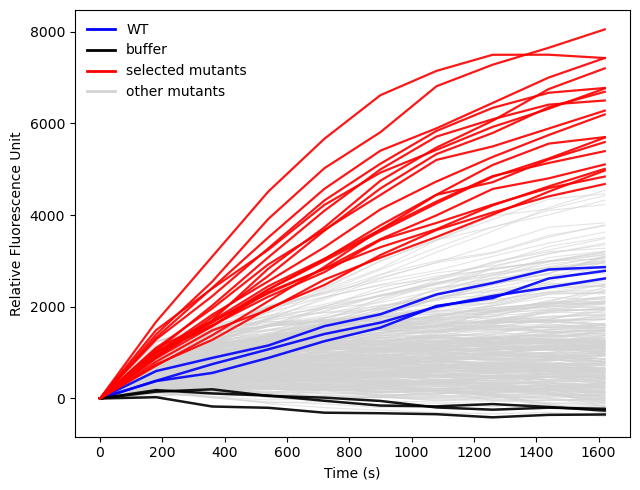

In [8]:
import matplotlib.pyplot as plt

black_designs = [
    "chainA_A30V",
    "chainA_F48W",
    "chainA_A73V",
    "chainA_A75E",
    "chainA_A75P",
    "chainA_A79D",
    "chainA_A79E",
    "chainA_A79H",
    "chainA_A79K",
    "chainA_A79N",
    "chainA_A79Q",
    "chainA_Y83D",
    "chainA_Y83Q",
    "chainA_A84Y",
    "chainA_V121I",
    "chainA_Y152I",
    "chainA_Y152M",
    "chainA_Y152R",
    "chainA_Y152V",
] ### > 1.5 fold improvement

# Make a copy to avoid modifying original dataframe
df_plot = df_merged[df_merged["time"]<1800].copy()

# Baseline subtraction: subtract t=0 value per well
df_plot["sfGFP_RFU_baseline_sub"] = (
    df_plot["sfGFP_RFU"]
    - df_plot.groupby("well_name")["sfGFP_RFU"].transform("first")
)

# Create figure
plt.figure(figsize=(6.5, 5))

# Plot all curves in light gray first
for well, g in df_plot.groupby("well_name"):
    plt.plot(
        g["time"],
        g["sfGFP_RFU_baseline_sub"],
        color="lightgray",
        linewidth=0.8,
        alpha=0.6
    )

# Highlight WT in red
df_wt = df_plot[df_plot["design_name"] == "wt"]
for well, g in df_wt.groupby("well_name"):
    plt.plot(
        g["time"],
        g["sfGFP_RFU_baseline_sub"],
        color="blue",
        linewidth=1.8,
        alpha=0.9
    )

# Highlight blank in blue
df_blank = df_plot[df_plot["design_name"] == "blank"]
for well, g in df_blank.groupby("well_name"):
    plt.plot(
        g["time"],
        g["sfGFP_RFU_baseline_sub"],
        color="black",
        linewidth=1.8,
        alpha=0.9
    )
    
# Highlight selected mutants in black
df_black = df_plot[df_plot["design_name"].isin(black_designs)]

for well, g in df_black.groupby("well_name"):
    plt.plot(
        g["time"],
        g["sfGFP_RFU_baseline_sub"],
        color="red",
        linewidth=1.6,
        alpha=0.9
    )


# Labels and formatting
plt.xlabel("Time (s)")
plt.ylabel("Relative Fluorescence Unit")
# plt.title("sfGFP kinetics (baseline-subtracted)")

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="blue", lw=2, label="WT"),
    Line2D([0], [0], color="black", lw=2, label="buffer"),
    Line2D([0], [0], color="red", lw=2, label="selected mutants"),
    Line2D([0], [0], color="lightgray", lw=2, label="other mutants"),
]


plt.legend(
    handles=legend_elements,
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.savefig("ssm_activity_screen.png",dpi=300)
plt.show()


In [9]:
df_merged.time.unique()

array([   0,  180,  360,  540,  720,  900, 1080, 1260, 1440, 1620, 1800,
       1980, 2160, 2340, 2520, 2700, 2880, 3060, 3240, 3420, 3600, 3780,
       3960, 4140, 4320, 4500, 4680, 4860, 5040, 5220, 5400, 5580, 5760,
       5940, 6120, 6300, 6480, 6660, 6840, 7020, 7200])

## Calculate fold improvement

In [10]:

import numpy as np
import pandas as pd

# Ensure correct ordering
df_sorted = df_merged.sort_values(["well_name", "time"]).copy()

# ---- 1. Compute slope from 540–900 s window (4th–6th points) ----
def slope_540_900(group):
    g = group.iloc[2:5]  # 4th, 5th, 6th points (e.g. 540, 720, 900)
    g = g.dropna(subset=["sfGFP_RFU"])
    if len(g) < 2:
        return np.nan
    return np.polyfit(g["time"].to_numpy(), g["sfGFP_RFU"].to_numpy(), 1)[0]

slopes = (
    df_sorted
    .groupby("well_name")[["time", "sfGFP_RFU"]]
    .apply(slope_540_900)
    .rename("slope_raw")
    .reset_index()
)

# ---- 2. Attach metadata (one row per well) ----
well_metadata = (
    df_sorted
    .drop_duplicates("well_name")
    [
        [
            "well_name",
            "source_plate_number",
            "source_plate_well_id",
            "design_name",
        ]
    ]
)

df_well_slopes = well_metadata.merge(slopes, on="well_name", how="left")

# ---- 3. Background subtraction using blank wells ----
blank_mean_slope = (
    df_well_slopes
    .loc[df_well_slopes["design_name"] == "blank", "slope_raw"]
    .mean()
)

df_well_slopes["slope"] = df_well_slopes["slope_raw"] - blank_mean_slope

# ---- 4. Compute WT mean slope (after blank subtraction) ----
wt_mean_slope = (
    df_well_slopes
    .loc[df_well_slopes["design_name"] == "wt", "slope"]
    .mean()
)

# ---- 5. Compute fold over WT (blank-corrected) ----
df_well_slopes["fold_over_wt"] = df_well_slopes["slope"] / wt_mean_slope

# ---- 6. Collapse to one row per design ----
df_improvement = (
    df_well_slopes
    .groupby("design_name", as_index=False)
    .agg(
        source_plate_number=("source_plate_number", "first"),
        source_plate_well_id=("source_plate_well_id", "first"),
        slope=("slope", "mean"),
        fold_over_wt=("fold_over_wt", "mean"),
        n_wells=("well_name", "nunique"),
    )
)


In [11]:
df_improvement.head()

,design_name,source_plate_number,source_plate_well_id,slope,fold_over_wt,n_wells
0,blank,8,H10,-3.700743e-17,-1.619075e-17,3
1,chainA_A159D,8,D4,7.305556e-01,3.133439e-01,1
2,chainA_A159E,8,D5,8.194444e-01,3.514694e-01,1
3,chainA_A159F,8,D6,5.361111e-01,2.299444e-01,1
4,chainA_A159G,8,D7,1.747222e+00,7.494043e-01,1


## Plot heatmap

In [12]:
## parse mutations
import re

df_hm = df_improvement.copy()

def parse_mutation(name):
    if name == "wt":
        return None, None, None
    m = re.search(r"_([A-Z])(\d+)([A-Z])$", name)
    if m:
        return m.group(1), int(m.group(2)), m.group(3)
    return None, None, None

df_hm[["wt_aa", "position", "mut_aa"]] = (
    df_hm["design_name"]
    .apply(lambda x: pd.Series(parse_mutation(x)))
)


In [13]:
## determine WT per position

wt_map = (
    df_hm
    .dropna(subset=["position"])
    .groupby("position")["wt_aa"]
    .first()
)


In [14]:
## pivot into hm matrix
heatmap_df = (
    df_hm
    .dropna(subset=["position", "mut_aa"])
    .pivot(
        index="mut_aa",
        columns="position",
        values="fold_over_wt"
    )
)

# Explicitly set WT cells to 1.0
for pos, wt_aa in wt_map.items():
    if pos in heatmap_df.columns and wt_aa in heatmap_df.index:
        heatmap_df.loc[wt_aa, pos] = 1.0


In [15]:
## choose order
aa_order = list("ADEFGHIKLMNPQRSTVWY")
heatmap_df = heatmap_df.reindex(aa_order)


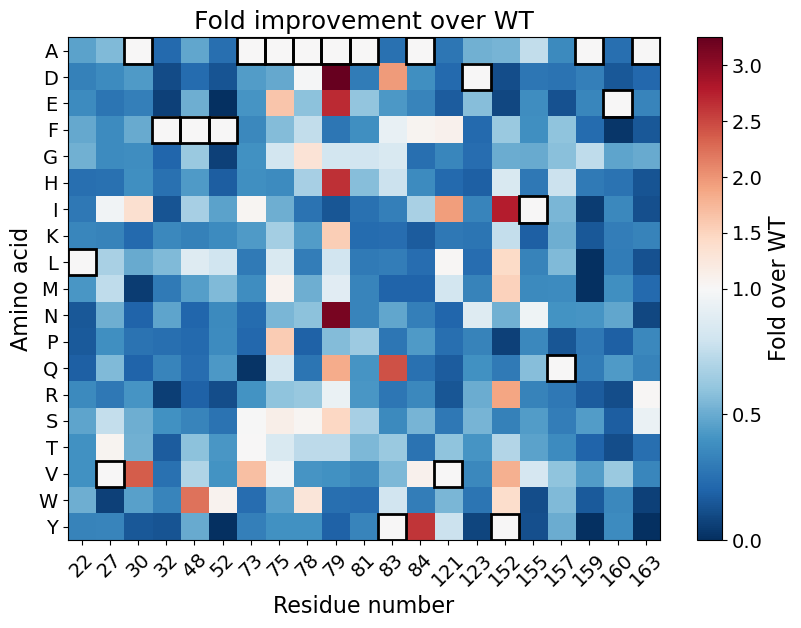

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

# Global font scaling
plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(
    figsize=(0.4 * heatmap_df.shape[1] , 6.5)
)

norm = TwoSlopeNorm(
    vmin=0,
    vcenter=1.0,
    vmax=heatmap_df.max().max()
)

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm
)

# Axes ticks
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels([int(x) for x in heatmap_df.columns], fontsize=16,rotation=45)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=16)

# Axis labels + title
ax.set_xlabel("Residue number", fontsize=16)
ax.set_ylabel("Amino acid", fontsize=16)
ax.set_title("Fold improvement over WT", fontsize=18)

# Tick mark size
ax.tick_params(axis="both", labelsize=14)

# # Annotate values
# for i in range(heatmap_df.shape[0]):
#     for j in range(heatmap_df.shape[1]):
#         val = heatmap_df.iat[i, j]
#         if not np.isnan(val):
#             ax.text(
#                 j, i, f"{val:.1f}",
#                 ha="center", va="center",
#                 fontsize=12,
#                 color="black"
#             )

# WT outline
for j, pos in enumerate(heatmap_df.columns):
    wt_aa = wt_map.get(pos)
    if wt_aa in heatmap_df.index:
        i = heatmap_df.index.get_loc(wt_aa)
        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                fill=False,
                edgecolor="black",
                linewidth=2
            )
        )

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fold over WT", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(
    "heatmap_all.png",
    dpi=300,              # high resolution for publication
    bbox_inches="tight"   # trims extra whitespace
)

plt.show()


In [1]:
import os
os.getcwd()

'/mnt/home/achen918/experiment_data/catalytic_binders/260112_ssm_purification'

## final publication 5c and 5d

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

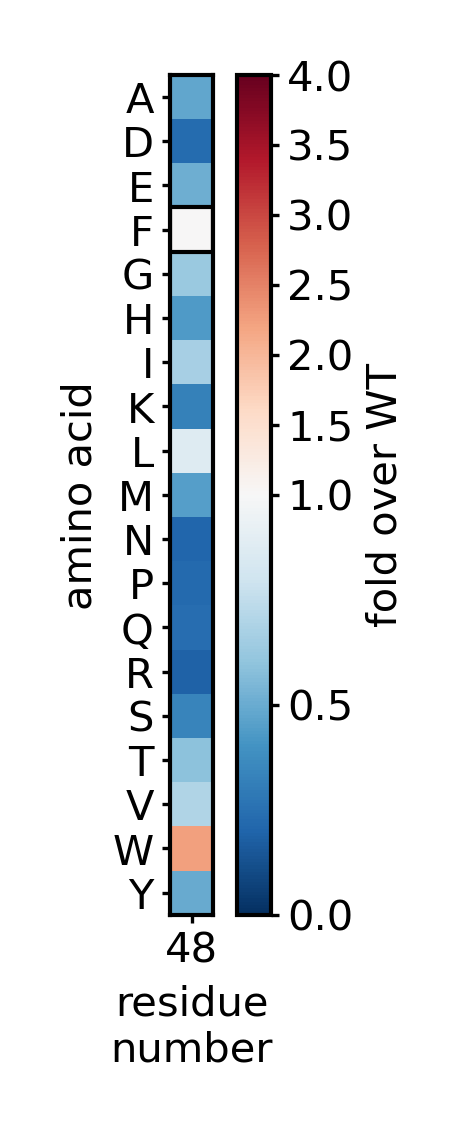

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

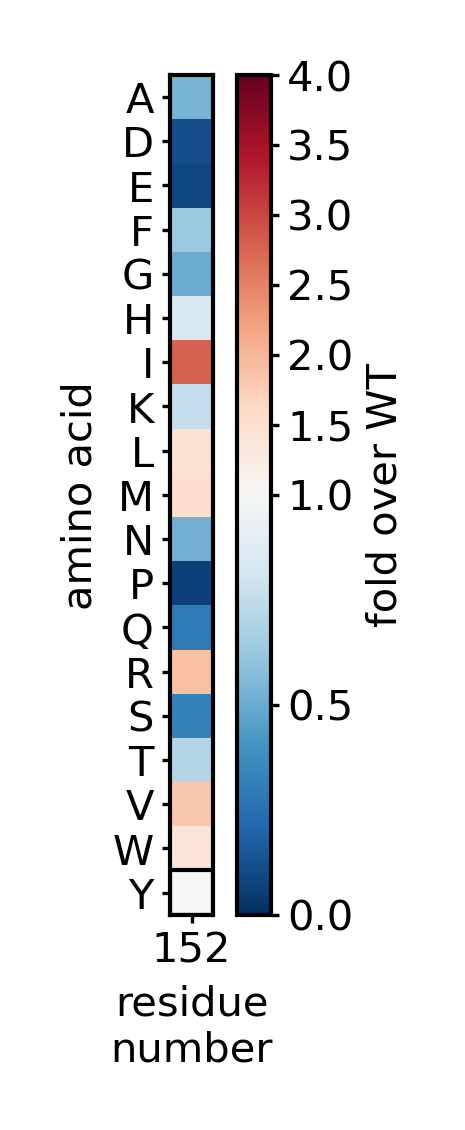

In [18]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# rebuild the font cache once so Arial is picked up
if "Arial" not in {f.name for f in fm.fontManager.ttflist}:
    fm._load_fontmanager(try_read_cache=False)

mm_to_inch = 1 / 25.4

# figure 5c -> residue 48, figure 5d -> residue 152
FIGURES = [(48, "5c"), (152, "5d")]

# 16 mm wide x 40 mm tall
FIG_W_MM = 16.0
FIG_H_MM = 44.0

# --- style: Arial, all text 5 pt -----------------------------------------
rc = {
    # name Arial directly rather than via the sans-serif fallback chain, so the
    # svg carries font-family:'Arial' everywhere instead of a list ending in
    # "sans-serif" (which Inkscape/Illustrator resolve to a generic sans)
    "font.family": "Arial",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial",
    "mathtext.bf": "Arial:bold",
    "mathtext.default": "regular",
    "font.size": 5,
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.major.size": 1.0,
    "ytick.major.size": 1.0,
    "svg.fonttype": "none",   # keep text editable/selectable in the SVG
    "pdf.fonttype": 42,
}

with mpl.rc_context(rc):
    for position, panel in FIGURES:
        heatmap_subset = heatmap_df[[position]]

        fig, ax = plt.subplots(
            figsize=(FIG_W_MM * mm_to_inch, FIG_H_MM * mm_to_inch),
            dpi=600,
        )

        norm = TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=4)

        im = ax.imshow(
            heatmap_subset.values,
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
        )

        ax.set_xticks(np.arange(len(heatmap_subset.columns)))
        ax.set_xticklabels(heatmap_subset.columns.astype(int))
        ax.set_yticks(np.arange(len(heatmap_subset.index)))
        ax.set_yticklabels(heatmap_subset.index)

        ax.set_xlabel("residue\nnumber", labelpad=1.5)
        ax.set_ylabel("amino acid", labelpad=1.5)
        ax.tick_params(pad=1)

        # WT outline
        for j, pos in enumerate(heatmap_subset.columns):
            wt_aa = wt_map.get(pos)
            if wt_aa in heatmap_subset.index:
                i = heatmap_subset.index.get_loc(wt_aa)
                ax.add_patch(
                    Rectangle(
                        (j - 0.5, i - 0.5), 1, 1,
                        fill=False, edgecolor="black", linewidth=0.5,
                    )
                )

        # Colorbar
        divider = make_axes_locatable(ax)
        # pad is in inches: 0.04 in = 1.0 mm
        cax = divider.append_axes("right", size="80%", pad=0.04)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label("fold over WT", labelpad=1.5)
        cbar.ax.tick_params(labelsize=5, pad=1, width=0.4, length=1.0)
        cbar.outline.set_linewidth(0.5)

        # Explicit margins keep the canvas exactly 16 x 40 mm
        # (do NOT use tight_layout or bbox_inches="tight", they change the size)
        fig.subplots_adjust(left=0.295, right=0.56, top=0.978, bottom=0.17)

        fig.savefig(f"fig_{panel}_heatmap_position_{position}.svg",
                    format="svg", dpi=600)
        fig.savefig(f"fig_{panel}_heatmap_position_{position}.png",
                    format="png", dpi=600)
        plt.show()


In [1]:
import os
os.getcwd()

'/mnt/home/achen918/experiment_data/catalytic_binders/260112_ssm_purification'

In [18]:
### Wells to repeat

def well_sort_key(well_id):
    row = well_id[0]
    col = int(well_id[1:])
    return (row, col)

df_improved = df_improvement[df_improvement["fold_over_wt"]>1.5].copy()

df_ordered = (
    df_improved
    .sort_values(
        by=["source_plate_number", "source_plate_well_id"],
        key=lambda s: s.map(well_sort_key) if s.name == "source_plate_well_id" else s
    )
)

df_ordered[
    [
        "source_plate_number",
        "source_plate_well_id",
        "design_name",
        "slope",
        "fold_over_wt",
    ]
].to_csv("hits_to_repeat.csv")


In [19]:
df_ordered.design_name ## go back to progress curve plotting

52      chainA_A30V
233     chainA_F48W
70      chainA_A73V
74      chainA_A75E
83      chainA_A75P
109     chainA_A79D
110     chainA_A79E
113     chainA_A79H
115     chainA_A79K
118     chainA_A79N
120     chainA_A79Q
362     chainA_Y83D
373     chainA_Y83Q
162     chainA_A84Y
313    chainA_V121I
349    chainA_Y152I
352    chainA_Y152M
356    chainA_Y152R
359    chainA_Y152V
Name: design_name, dtype: object

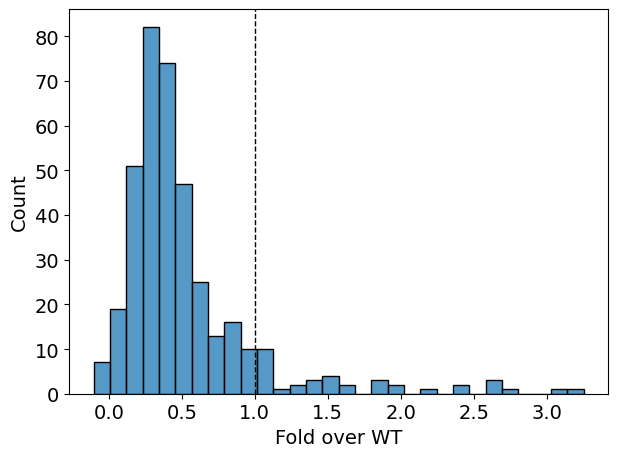

Variants above WT (>1.0): 37
Variants below WT (<1.0): 342
Variants equal to WT (=1.0): 1


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df_improvement,
    x="fold_over_wt",
    bins=30
)

plt.axvline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Fold over WT")
plt.tight_layout()
plt.show()

n_above = (df_improvement["fold_over_wt"] > 1.0).sum()
n_below = (df_improvement["fold_over_wt"] < 1.0).sum()
n_equal = (df_improvement["fold_over_wt"] == 1.0).sum()

print(f"Variants above WT (>1.0): {n_above}")
print(f"Variants below WT (<1.0): {n_below}")
print(f"Variants equal to WT (=1.0): {n_equal}")


In [21]:
df_improvement.to_csv("260113_screening_result.csv")

# Check correlation w computational metrics

In [22]:
import pandas as pd
input_csv = '/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex_analysis/folding_out/af3_data.csv'
df_af3_metrics = pd.read_csv(input_csv)
df_af3_metrics.head()

### merge computational metrics with wet-lab improvement

# Make lowercase helper columns for a case-insensitive merge
df_af3_metrics["_description_ci"] = (
    df_af3_metrics["description"].str.lower().str.strip()
)

df_improvement["_design_name_ci"] = (
    df_improvement["design_name"].str.lower().str.strip()
)

# Merge the dataframes
df_merged = df_af3_metrics.merge(
    df_improvement,
    left_on="_description_ci",
    right_on="_design_name_ci",
    how="inner"  # change to 'left', 'right', or 'outer' if needed
)

# (Optional) Drop helper columns after merge
df_merged = df_merged.drop(columns=["_description_ci", "_design_name_ci"])

df_merged.to_csv("260124_af3_complex_metrics_wetlab_fold_improvement.csv")



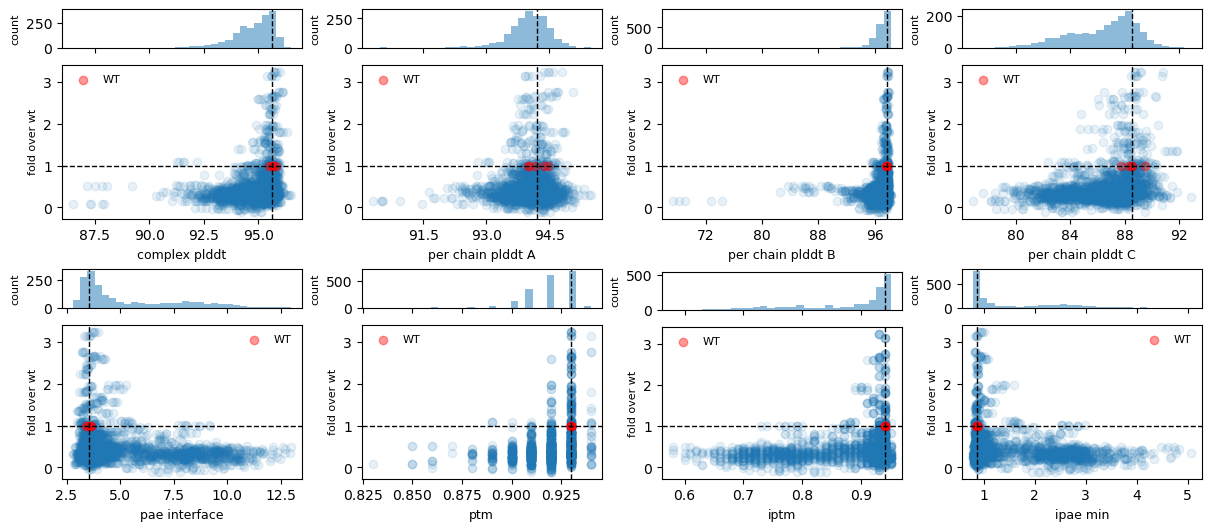

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# create output directory
output_dir = "af3_predicability"
os.makedirs(output_dir, exist_ok=True)

metrics = [
    "complex_plddt",
    "per_chain_plddt_A",
    "per_chain_plddt_B",
    "per_chain_plddt_C",
    "pae_interface",
    "ptm",
    "iptm",
    "ipae_min",
]

# ---- CREATE ONE FIGURE WITH 2x4 METRICS ----
fig = plt.figure(figsize=(12, 5.2), constrained_layout=True)
outer_gs = fig.add_gridspec(nrows=2, ncols=4)

for i, m in enumerate(metrics):

    d = df_merged[["fold_over_wt", m, "design_name"]].dropna()
    if d.empty:
        continue

    row = i // 4   # 4 columns per row
    col = i % 4

    # inner layout: histogram on top, scatter below
    inner_gs = outer_gs[row, col].subgridspec(2, 1, height_ratios=[1, 4])

    ax_hist = fig.add_subplot(inner_gs[0])
    ax_scatter = fig.add_subplot(inner_gs[1], sharex=ax_hist)

    is_wt = d["design_name"].str.lower() == "wt"

    if is_wt.any():
        wt_mean_x = d.loc[is_wt, m].mean()
    else:
        wt_mean_x = np.nan

    # histogram
    ax_hist.hist(d[m].values, bins=30, alpha=0.5)
    ax_hist.set_ylabel("count", fontsize=8)
    ax_hist.tick_params(axis="x", labelbottom=False)

    if np.isfinite(wt_mean_x):
        ax_hist.axvline(wt_mean_x, linestyle="--", color="black", linewidth=1)

    # scatter
    ax_scatter.scatter(
        d.loc[~is_wt, m],
        d.loc[~is_wt, "fold_over_wt"],
        alpha=0.1
    )

    ax_scatter.scatter(
        d.loc[is_wt, m],
        d.loc[is_wt, "fold_over_wt"],
        color="red",
        alpha=0.4,
        label="WT",
    )

        # ---- FONT SIZES ----
    title_size = 12
    label_size = 11
    tick_size = 10
    legend_size = 9

    # histogram ticks
    ax_hist.tick_params(axis="both", labelsize=tick_size)

    # scatter ticks
    ax_scatter.tick_params(axis="both", labelsize=tick_size)

    # labels
    clean_label = m.replace("_", " ")
    ax_scatter.set_xlabel(clean_label, fontsize=label_size)
    ax_scatter.set_ylabel("Fold over WT", fontsize=label_size)

    # title
    # ax_scatter.set_title(clean_label, fontsize=title_size)
    
    ## tick marks
    ax_scatter.xaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))

    # legend
    if is_wt.any():
        ax_scatter.legend(frameon=False, fontsize=legend_size)

    if np.isfinite(wt_mean_x):
        ax_scatter.axvline(wt_mean_x, linestyle="--", color="black", linewidth=1)
        ax_scatter.axhline(1, linestyle="--", color="black", linewidth=1)

    clean_label = m.replace("_", " ")

    ax_scatter.set_xlabel(clean_label, fontsize=9)
    ax_scatter.set_ylabel("fold over wt", fontsize=8)
    # ax_scatter.set_title(clean_label, fontsize=10)

    if is_wt.any():
        ax_scatter.legend(frameon=False, fontsize=8)

# save combined figure
out_path = os.path.join(output_dir, "fold_over_wt_vs_all_metrics_grid_2x4.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()